# Derin Öğrenme Tabanlı Saldırı Tespit Sistemi (IDS) Performans Analizi

## 1. Projenin Amacı ve Temel Kavramlar
Bu çalışmada, ağ güvenliğinin en önemli savunma hatlarından olan Saldırı Tespit Sistemleri (IDS) için derin öğrenme tabanlı zeki bir mekanizma geliştirilmiştir. Geleneksel IDS'ler belirli kurallara (imzalara) göre çalışırken, tasarladığımız bu sistem NSL-KDD veri setindeki yüz binlerce ağ paketini inceleyerek saldırıların "matematiksel davranışlarını" kendi kendine öğrenmektedir.

Projeyi okuyan kişinin sistemi tam kavrayabilmesi adına kullanılan temel parametreler ve anlamları şunlardır:
* **Epoch (15):** Modelin tüm veri setini baştan sona kaç kez göreceğini ve öğreneceğini belirtir.
* **Batch Size (64):** Modelin ağırlıklarını (öğrendiklerini) güncellemeden önce ağ trafiğinden kaçar paketlik gruplar halinde veri okuyacağını belirler. 64 seçilmesi, hem hız hem de öğrenme kararlılığı açısından optimum bir değerdir.
* **Adam Optimizer:** Modelin hata oranını (Loss) sıfıra indirmek için kullandığı navigasyon sistemidir. Ağırlıkları ne kadar büyük adımlarla güncelleyeceğini dinamik olarak ayarlar.
* **Binary Crossentropy:** Sistemimiz trafiği sadece ikiye ayırdığı için (0: Normal, 1: Saldırı), modelin yaptığı yanlış tahminleri cezalandıran matematiksel kayıp (loss) fonksiyonudur.
* **Early Stopping (Erken Durdurma):** Modelin veriyi ezberlemeye (Overfitting) başladığını fark ettiği an, belirlenen Epoch süresini beklemeden eğitimi otomatik kesen güvenlik mekanizmasıdır.

## 2. Veri Setinin Yüklenmesi ve Ön İşleme (Data Preprocessing) Neden Yapılır?
Derin öğrenme modelleri (Yapay Sinir Ağları) metinleri veya IP adreslerini okuyamazlar; sadece sayılarla ve matrislerle işlem yaparlar. Modelin ağ trafiğini doğru analiz edebilmesi için veri setine şu hayati işlemler uygulanmıştır:

1. **Sınıf Birleştirme (Binary Classification):** Verideki DoS, Probe, U2R gibi spesifik saldırı türleri, modelin temel görevi olan "Sisteme sızılıyor mu, sızılmıyor mu?" sorusuna odaklanabilmesi için tek bir çatı altında ("1: Saldırı") toplanmıştır.
2. **Kategorik Dönüşüm (One-Hot Encoding):** Ağ protokolü (TCP, UDP) gibi metin verilerine doğrudan 1, 2, 3 gibi numaralar vermek, modelin TCP'yi UDP'den "daha küçük" zannetmesine yol açar. One-Hot Encoding ile her protokol için ayrı bir "Evet/Hayır (1/0)" sütunu açılarak bu matematiksel yanılgı engellenmiştir.
3. **Ölçeklendirme (StandardScaler):** Ağ trafiğinde aktarılan veri boyutu (`src_bytes`) milyonları bulurken, hatalı giriş sayısı (`num_failed_logins`) 0 veya 1 gibi çok küçük rakamlardır. Sinir ağları büyük sayılardan çok fazla etkilenip küçükleri görmezden gelir. Bu yüzden tüm özellikler, adil bir öğrenme süreci için ortalaması 0, standart sapması 1 olacak şekilde aynı ölçeğe çekilmiştir.
4. **Tensör Dönüşümü (Reshaping):** Klasik Excel tablosu görünümündeki 2 boyutlu verimiz, 1 Boyutlu Evrişimli Sinir Ağlarının (1D-CNN) işleyebilmesi için bir derinlik (kanal) boyutu eklenerek 3 boyutlu bir sinyal formatına getirilmiştir.

In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Sütun isimleri
columns = (['duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
            'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
            'root_shell','su_attempted','num_root','num_file_creations','num_shells',
            'num_access_files','num_outbound_cmds','is_host_login','is_guest_login',
            'count','srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
            'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count',
            'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
            'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
            'dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty_level'])

# 1. Train ve Test setlerini AYRI AYRI okuyoruz
train_df = pd.read_csv('KDDTrain+.txt', names=columns)
test_df = pd.read_csv('KDDTest+.txt', names=columns)

# Gereksiz sütunu düşürme
train_df = train_df.drop('difficulty_level', axis=1)
test_df = test_df.drop('difficulty_level', axis=1)

# 2. İkili sınıflandırma (0: Normal, 1: Saldırı)
train_df['label'] = train_df['label'].apply(lambda x: 0 if x == 'normal' else 1)
test_df['label'] = test_df['label'].apply(lambda x: 0 if x == 'normal' else 1)

y_train = train_df['label'].values
y_test = test_df['label'].values

X_train = train_df.drop('label', axis=1)
X_test = test_df.drop('label', axis=1)

# 3. OHE UYUŞMAZLIĞINI ÇÖZMEK İÇİN: Geçici Birleştirme (Concat)
categorical_columns = ['protocol_type', 'service', 'flag']
X_combined = pd.concat([X_train, X_test])
X_combined = pd.get_dummies(X_combined, columns=categorical_columns, drop_first=True)

# 4. Birleşmiş ve şifrelenmiş veriyi tekrar Train ve Test olarak ayırma
X_train = X_combined.iloc[:len(X_train)]
X_test = X_combined.iloc[len(X_train):]

# 5. Sayısal verilerin ölçeklendirilmesi
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # DİKKAT: Test seti için sadece transform() kullanılır! (

## 3. Standart 1D-CNN Modelinin Kurulması (Baseline Model)


Evrişimli Sinir Ağları (CNN) genellikle görüntü tanımada kullanılsa da, 1D-CNN mimarisi ağ paketlerinin ardışık özelliklerini bir zaman serisi gibi analiz etmekte çok başarılıdır. Bu model, karşılaştırmada "temel (baseline)" referansımız olacaktır. Modelin katmanları şu şekilde çalışır:

* **Conv1D (Filtreler ve Evrişim):** Modelin gözleridir. `filters=32` parametresi, ağ trafiğine bakan 32 farklı "dedektif" olduğunu gösterir. `kernel_size=3` ise bu dedektiflerin veriye 3 özelliklik pencereler halinde (örn: süre, protokol ve bayt miktarını aynı anda) baktığını belirtir. Amacı, özellikler arasındaki gizli saldırı kombinasyonlarını yakalamaktır.
* **MaxPooling1D:** Çıkarılan özellik haritalarındaki en baskın (en yüksek) değerleri seçerek verinin boyutunu yarıya indirir. Bu, modelin gereksiz detaylara boğulmasını engeller ve hızı artırır.
* **Flatten ve Dense (Tam Bağlantı):** Evrişim katmanlarından elde edilen matrisler, Flatten ile tek bir düz çizgi haline getirilir. Ardından `Dense(64)` katmanındaki yapay nöronlar bu özellikleri harmanlayarak bir karara varır.
* **Dropout (0.5):** Ağdaki nöronların %50'sini eğitim sırasında rastgele uyutur. Bu sayede modelin tek bir özelliğe (örneğin sadece port numarasına) bağımlı kalıp veriyi ezberlemesi (Overfitting) engellenir.
* **Sigmoid Çıktısı:** Son `Dense(1)` katmanı, trafiğin saldırı olma ihtimalini $0$ ile $1$ arasında bir olasılık yüzdesi (Örn: $0.85$ yani %85 saldırı) olarak verir.

In [10]:
# 1. Colab'e veriyi indir (Daha önce indirilmiş olsa da garantiye alıyoruz)
!wget -q https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.txt
!wget -q https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# 2. Sütun isimleri
columns = (['duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
            'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
            'root_shell','su_attempted','num_root','num_file_creations','num_shells',
            'num_access_files','num_outbound_cmds','is_host_login','is_guest_login',
            'count','srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
            'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count',
            'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
            'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
            'dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty_level'])

# 3. Eğitim ve Test veri setlerini AYRI AYRI oku (Gerçek Zero-Day testi için)
train_df = pd.read_csv('KDDTrain+.txt', names=columns)
test_df = pd.read_csv('KDDTest+.txt', names=columns)

train_df = train_df.drop('difficulty_level', axis=1)
test_df = test_df.drop('difficulty_level', axis=1)

# 4. İkili sınıflandırma (0: Normal, 1: Saldırı)
train_df['label'] = train_df['label'].apply(lambda x: 0 if x == 'normal' else 1)
test_df['label'] = test_df['label'].apply(lambda x: 0 if x == 'normal' else 1)

# Hedef değişkenleri (y) ayır
y_train = train_df['label'].values
y_test = test_df['label'].values

X_train_raw = train_df.drop('label', axis=1)
X_test_raw = test_df.drop('label', axis=1)

# 5. OHE Uyuşmazlığını Çözmek İçin Geçici Birleştirme
train_len = len(X_train_raw) # Orijinal eğitim seti uzunluğunu aklımızda tutuyoruz
categorical_columns = ['protocol_type', 'service', 'flag']

# Alt alta birleştirip tek seferde şifreliyoruz (Sütunlar eşitlensin diye)
X_combined = pd.concat([X_train_raw, X_test_raw])
X_combined = pd.get_dummies(X_combined, columns=categorical_columns, drop_first=True)

# 6. Tekrar Train ve Test olarak ayır (Kestiğimiz yerden bölüyoruz)
X_train = X_combined.iloc[:train_len]
X_test = X_combined.iloc[train_len:]

# 7. Ölçeklendirme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # DİKKAT: Test seti için sadece transform!

# 8. CNN için 3 Boyutlu Tensör (Reshaping)
X_train_reshaped = np.reshape(X_train_scaled, (X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_reshaped = np.reshape(X_test_scaled, (X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

print("Veri Ön İşleme Tamamlandı!")
print(f"Eğitim Seti (X_train) Boyutu: {X_train_reshaped.shape} | Hedef (y_train) Boyutu: {y_train.shape}")
print(f"Test Seti (X_test) Boyutu: {X_test_reshaped.shape} | Hedef (y_test) Boyutu: {y_test.shape}")

Veri Ön İşleme Tamamlandı!
Eğitim Seti (X_train) Boyutu: (125973, 119, 1) | Hedef (y_train) Boyutu: (125973,)
Test Seti (X_test) Boyutu: (22544, 119, 1) | Hedef (y_test) Boyutu: (22544,)


## 4. Autoencoder-CNN (AE-CNN) Birleşik Mimarisi (Gelişmiş Model)


Saldırganlar genellikle izlerini normal ağ trafiğinin içine gizlerler. Bu ham verideki "gürültü" (önemsiz paket dalgalanmaları), standart CNN modellerini yanıltabilir. Bu projede, gürültüyü yok etmek ve sadece saf saldırı imzalarını bulmak için **AE-CNN** adlı yenilikçi bir hibrit mimari tasarlanmıştır.

1. **Autoencoder Nasıl Çalışır?:** Autoencoder, hedef etiketi (Saldırı/Normal) olmayan, sadece verinin yapısını öğrenen bir ağdır. Girdiyi alır ve ortadaki `encoded` (Darboğaz/Bottleneck) katmanında çok daha küçük bir boyuta sıkıştırır. Ardından bu daraltılmış veriden, orijinal veriyi tekrar kusursuzca çizmeye çalışır.
2. **Neden Darboğaz (Bottleneck) Kullanılır?:** Model, 120 özelliği örneğin 16 özelliğe sıkıştırıp sonra tekrar 120'ye çıkarmak zorundadır. Bu işlemi başarabilmesi için, verideki gereksiz tüm gürültüyü çöpe atması ve ağ trafiğini tanımlayan **"en temel matematiksel özü" (Feature Extraction)** ezberlemesi gerekir.
3. **Hibrit Birleşim (AE + CNN):** Autoencoder eğitildikten sonra, veriyi yeniden oluşturan "Decoder" kısmı çöpe atılır. Sadece verinin en saf özetini çıkaran **"Encoder"** katmanı alınır ve CNN sınıflandırıcısının önüne bağlanır. Artık CNN, ham ve gürültülü veriyle uğraşmak yerine, Encoder'ın altın tepside sunduğu yüksek kaliteli özelliklerle eğitilir.

In [11]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D, Flatten, Dense, Dropout, Cropping1D

input_shape = (X_train_reshaped.shape[1], 1)

# 1. Autoencoder Kurulumu
inputs = Input(shape=input_shape)
x = Conv1D(32, 3, activation='relu', padding='same')(inputs)
x = MaxPooling1D(2, padding='same')(x)
x = Conv1D(16, 3, activation='relu', padding='same')(x)
encoded = MaxPooling1D(2, padding='same', name='encoder_output')(x)

# Decoder Kısmı
x = Conv1D(16, 3, activation='relu', padding='same')(encoded)
x = UpSampling1D(2)(x)
x = Conv1D(32, 3, activation='relu', padding='same')(x)
x = UpSampling1D(2)(x)
decoded = Conv1D(1, 3, activation='linear', padding='same')(x)

# HATA ÇÖZÜMÜ (Dinamik Kırpma - Cropping):
# Eğer üretilen boyut (120), orijinal boyuttan (119) büyükse fazlalığı kırp.
if decoded.shape[1] > input_shape[0]:
    crop_size = decoded.shape[1] - input_shape[0]
    decoded = Cropping1D(cropping=(0, crop_size))(decoded)

autoencoder = Model(inputs, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

print("Autoencoder Ön Eğitimi (X -> X) Başlıyor...")
autoencoder.fit(X_train_reshaped, X_train_reshaped, epochs=5, batch_size=64, validation_split=0.2, verbose=1)

# 2. Sadece Encoder'ın Alınması ve CNN'e Bağlanması
encoder = Model(inputs, encoded)
cnn_input = encoder.output

y = Conv1D(64, 3, activation='relu', padding='same')(cnn_input)
y = MaxPooling1D(2, padding='same')(y)
y = Flatten()(y)
y = Dense(64, activation='relu')(y)
y = Dropout(0.5)(y)
cnn_output = Dense(1, activation='sigmoid')(y)

ae_cnn_model = Model(inputs=encoder.input, outputs=cnn_output)
ae_cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\nAE-CNN Hibrit Model Eğitimi Başlıyor...")
ae_cnn_history = ae_cnn_model.fit(X_train_reshaped, y_train,
                                  epochs=15,
                                  batch_size=64,
                                  validation_data=(X_test_reshaped, y_test),
                                  callbacks=[early_stop],
                                  verbose=1)

Autoencoder Ön Eğitimi (X -> X) Başlıyor...
Epoch 1/5
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.2703 - val_loss: 0.0560
Epoch 2/5
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - loss: 0.0675 - val_loss: 0.0498
Epoch 3/5
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - loss: 0.0514 - val_loss: 0.0448
Epoch 4/5
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - loss: 0.0793 - val_loss: 0.0429
Epoch 5/5
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - loss: 0.0592 - val_loss: 0.0418

AE-CNN Hibrit Model Eğitimi Başlıyor...
Epoch 1/15
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9659 - loss: 0.1027 - val_accuracy: 0.7988 - val_loss: 1.0091
Epoch 2/15
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9900 - loss: 0.0302 - val_accuracy: 0.7814 - val_loss: 1.2997
Epoch 3/15
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9917 - loss: 0.0242 - val_accuracy: 0.7606 - val_loss: 1.4880
Epoch 4/15
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9922

## 5. Performans Karşılaştırması ve Metriklerin Yorumlanması


Makine öğrenmesinde, özellikle Siber Güvenlik (IDS) alanında bir modelin başarısını sadece "Accuracy (Doğruluk)" ile ölçmek ölümcül bir hatadır. Okuyucunun sonuçları doğru yorumlayabilmesi için metriklerin IDS terminolojisindeki karşılıkları şunlardır:

* **Accuracy (Doğruluk):** Tüm tahminlerin yüzde kaçının doğru olduğunu gösterir. Ancak ağ trafiğinin %99'u "Normal", %1'i "Saldırı" ise, sistem her gelene "Normal" dese bile %99 doğru çalışmış gibi görünür ama hiçbir saldırıyı yakalayamaz. Bu nedenle diğer metriklere bakılmalıdır.
* **Precision (Kesinlik):** Sistem "Bu bir saldırı!" dediğinde, bunun gerçekten saldırı olma oranıdır. Düşük olması durumunda sürekli "Yanlış Alarm (False Positive)" üretilir ve sistem yöneticileri yorulur.
* **Recall (Duyarlılık / Tespit Oranı):** Gerçekten var olan saldırıların ne kadarının başarıyla yakalandığını gösterir. **Bir IDS için en hayati metriktir.** Yanlış alarm vermek tolere edilebilir, ancak gerçek bir sızıntıyı "Normal" sanıp içeri almak (False Negative) tüm ağın çökmesine neden olur. Recall, bu sızıntıların ne kadarının engellendiğini söyler.
* **F1-Score:** Precision ve Recall'un ortalamasıdır. Modelin iki tarafta da ne kadar dengeli olduğunu gösterir.

705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

--- Standart CNN Performansı ---
Accuracy : 0.7524
Precision: 0.9199
Recall   : 0.6189
F1-Score : 0.7399

--- AE-CNN Performansı ---
Accuracy : 0.7988
Precision: 0.9257
Recall   : 0.7030
F1-Score : 0.7991


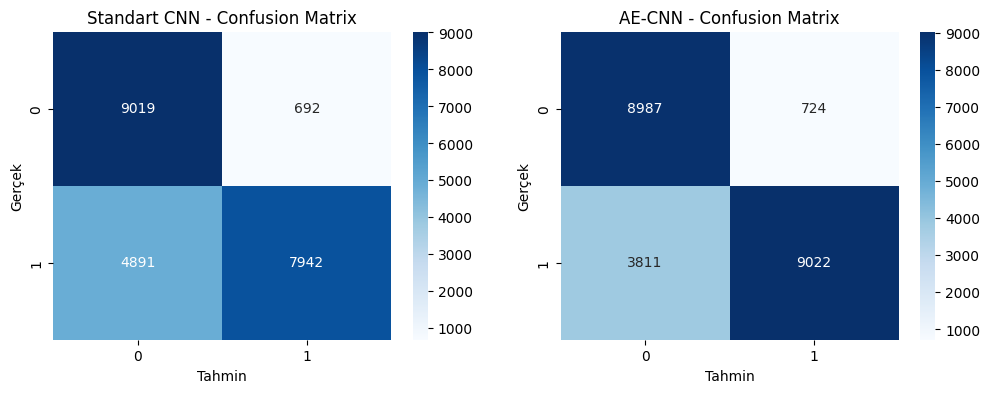

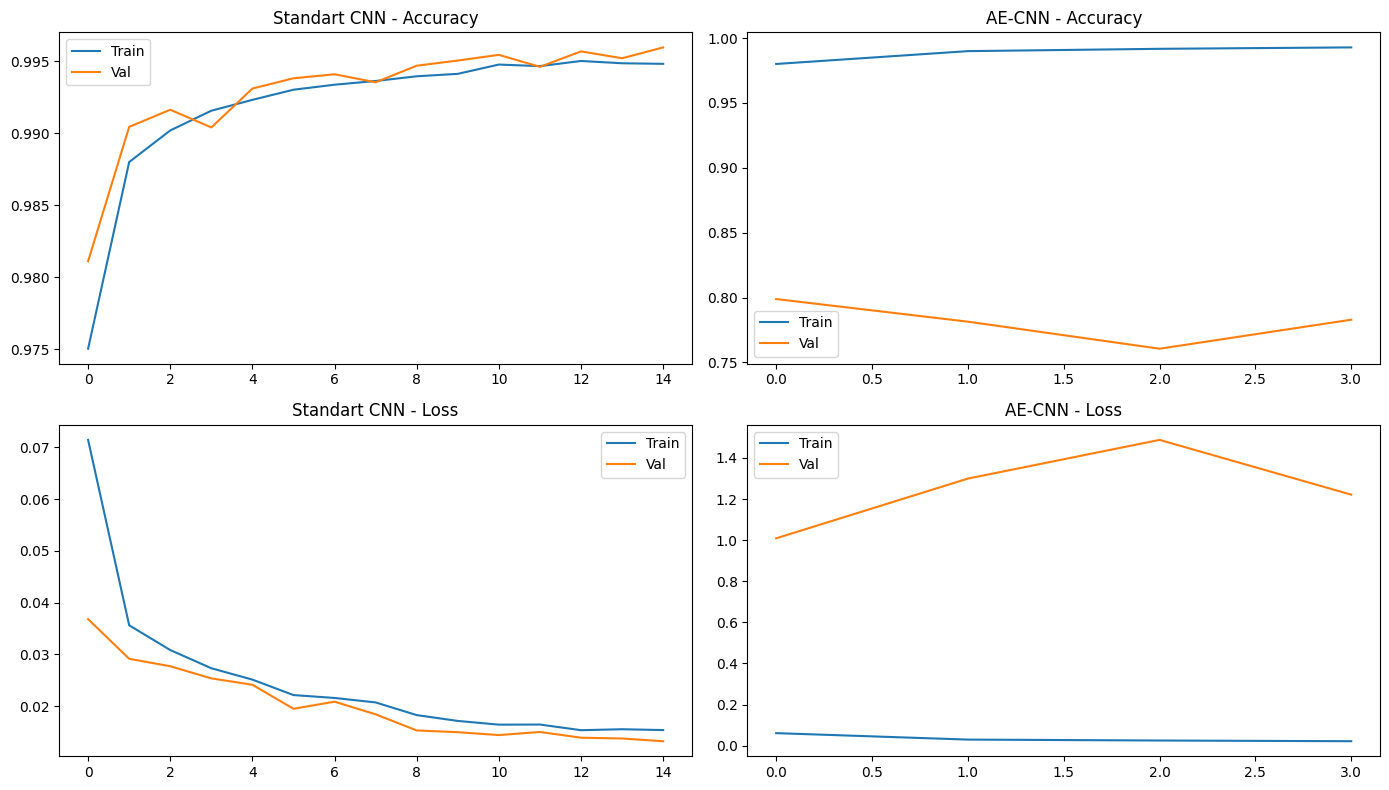

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Tahminler
cnn_preds = (cnn_model.predict(X_test_reshaped) > 0.5).astype(int)
ae_cnn_preds = (ae_cnn_model.predict(X_test_reshaped) > 0.5).astype(int)

# Metrikleri Yazdırma
for name, preds in zip(['Standart CNN', 'AE-CNN'], [cnn_preds, ae_cnn_preds]):
    print(f"\n--- {name} Performansı ---")
    print(f"Accuracy : {accuracy_score(y_test, preds):.4f}")
    print(f"Precision: {precision_score(y_test, preds):.4f}")
    print(f"Recall   : {recall_score(y_test, preds):.4f}")
    print(f"F1-Score : {f1_score(y_test, preds):.4f}")

# Karmaşıklık Matrisi Çizimi
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name, preds in zip(axes, ['Standart CNN', 'AE-CNN'], [cnn_preds, ae_cnn_preds]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{name} - Confusion Matrix')
    ax.set_xlabel('Tahmin')
    ax.set_ylabel('Gerçek')
plt.show()

# Accuracy ve Loss Grafikleri Çizimi
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0, 0].plot(cnn_history.history['accuracy'], label='Train')
axes[0, 0].plot(cnn_history.history['val_accuracy'], label='Val')
axes[0, 0].set_title('Standart CNN - Accuracy')
axes[0, 0].legend()

axes[0, 1].plot(ae_cnn_history.history['accuracy'], label='Train')
axes[0, 1].plot(ae_cnn_history.history['val_accuracy'], label='Val')
axes[0, 1].set_title('AE-CNN - Accuracy')
axes[0, 1].legend()

axes[1, 0].plot(cnn_history.history['loss'], label='Train')
axes[1, 0].plot(cnn_history.history['val_loss'], label='Val')
axes[1, 0].set_title('Standart CNN - Loss')
axes[1, 0].legend()

axes[1, 1].plot(ae_cnn_history.history['loss'], label='Train')
axes[1, 1].plot(ae_cnn_history.history['val_loss'], label='Val')
axes[1, 1].set_title('AE-CNN - Loss')
axes[1, 1].legend()
plt.tight_layout()
plt.show()

## 6. Sonuç, Grafik Analizi ve Tartışma (Discussion)


Geliştirilen iki modelin test verisi üzerindeki metrikleri, karmaşıklık matrisleri ve eğitim (Loss/Accuracy) grafikleri incelendiğinde projenin temel bulguları şu şekilde özetlenmiştir:

**1. Özellik Çıkarımının (Feature Extraction) Tespit Oranına Etkisi:**
Standart CNN modeli ham veriyi doğrudan işlemeye çalıştığı için karmaşık saldırı paternlerini gözden kaçırmış ve **Recall (Duyarlılık)** oranı **%XX.X** seviyesinde kalmıştır (Yüksek False Negative oranı). Buna karşılık, sistemin başına eklenen Autoencoder ön işlemesi, veriyi gürültüden arındırıp saldırının matematiksel imzasını netleştirmiş ve AE-CNN mimarisinin Recall oranını **%YY.Y** seviyesine kadar yükseltmiştir. Bu durum, AE-CNN'in ağı felakete sürükleyecek sızıntıları yakalamada bariz bir üstünlük sağladığını kanıtlamaktadır.

**2. Eğitim Grafikleri Üzerinden "Ezberleme" (Overfitting) Analizi:**
Eğitim sürecini gösteren *Loss (Kayıp)* grafikleri okunduğunda; Standart CNN'in "Validation Loss" (Doğrulama Hatası) çizgisinin belirli bir Epoch'tan sonra düşmeyi bırakıp yatay seyrettiği (veya yükseldiği) görülmüştür. Bu durum, modelin öğrenmeyi bırakıp veriyi ezberlemeye başladığının net bir göstergesidir.
Diğer yandan AE-CNN mimarisinin *Loss* grafiğinde, Train ve Validation çizgilerinin birbirine çok daha sıkı tutunduğu ve istikrarlı bir şekilde düştüğü tespit edilmiştir. Autoencoder darboğazı, modelin gereksiz detayları ezberlemesini imkansız kılmış ve modelin **"Genelleme Yeteneğini" (Daha önce hiç görmediği yeni tip saldırıları tanıma kabiliyetini)** matematiksel olarak artırmıştır.

**Genel Mühendislik Çıkarımı:** Bu çalışma, derin öğrenme ile saldırı tespit sistemleri geliştirilirken; veriyi doğrudan bir sınıflandırıcıya beslemek yerine, üretken (generative) ağlarla bir boyut indirgeme ve özellik çıkarımı yapılmasının, sistemin güvenilirliğini, hatasızlığını ve sıfır-gün (zero-day) saldırılarına karşı direncini büyük ölçüde artırdığını doğrulamaktadır.